---
title: "LSE DS202W 2025/2026: Week 08 - Student Notebook"
author: "MY NAME (MY CANDIDATE NUMBER)"
date: 10 March 2026
---

# Week 8 Labs - Clustering Analysis in Python (DS202)

## Overview (90 minutes total)

Today we'll explore different clustering algorithms and evaluation methods using Multiple Correspondence Analysis (MCA) coordinates. We'll compare k-means variants, k-medoids, and DBSCAN clustering approaches.

-   **Technical Skills:** Implement k-means, k-medoids, and DBSCAN algorithms with evaluation methods (elbow, silhouette) and adapt code templates across different clustering approaches

-   **Analytical Skills:** Compare clustering methods, evaluate their appropriateness for datasets, and interpret metrics to determine optimal cluster numbers and trade-offs

-   **Critical Thinking:** Justify algorithm selection based on data characteristics, assess outlier treatment decisions, and critique clustering limitations

-   **Practical Application:** Design complete clustering workflows, troubleshoot parameter selection challenges, and communicate results through effective visualizations

**Lab Structure:**
- 10 min: Clustering algorithms overview + k-means template
- 50 min: Student exploration of algorithms and evaluation methods
- 30 min: DBSCAN exploration

------------------------------------------------------------------------

## Part 1: Introduction to Clustering Algorithms (10 minutes)

### Key Differences Between Clustering Methods

| Algorithm | Centers | Distance | Outlier Sensitivity | Use Case |
|--------------|--------------|--------------|------------------|--------------|
| **k-means** | Computed centroids | Euclidean | High | Spherical clusters |
| **k-means++** | Smart initialization | Euclidean | High | Better initial centroids |
| **k-medoids** | Actual data points | Any metric | Low | Non-spherical clusters |
| **DBSCAN** | None (density-based) | Any metric | Very low | Arbitrary shapes |

### Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import pairwise_distances
import warnings
import kmedoids

warnings.filterwarnings("ignore")

# Load the MCA coordinates from Week 7
mca_coords = pd.read_csv("../data/mca-week-7.csv")

# If you have the actual MCA data file, uncomment the line below:
# mca_coords = pd.read_csv("../data/mca-week-7.csv")

print(f"Data shape: {mca_coords.shape}")
print(mca_coords.head())

Data shape: (36, 3)
      dim_1     dim_2                category
0 -0.558831 -0.175055  avoid_transport_fare_n
1  0.645299  0.202141  avoid_transport_fare_y
2 -0.416500 -0.210573     stealing_property_n
3  1.157445  0.585178     stealing_property_y
4 -0.515787 -0.230177        cheating_taxes_n


------------------------------------------------------------------------

## Part 2: K-means Template & Algorithm Applications (50 minutes)

### Step 1: Study the K-means Template (15 minutes)

Here's the complete workflow for k-means clustering evaluation:

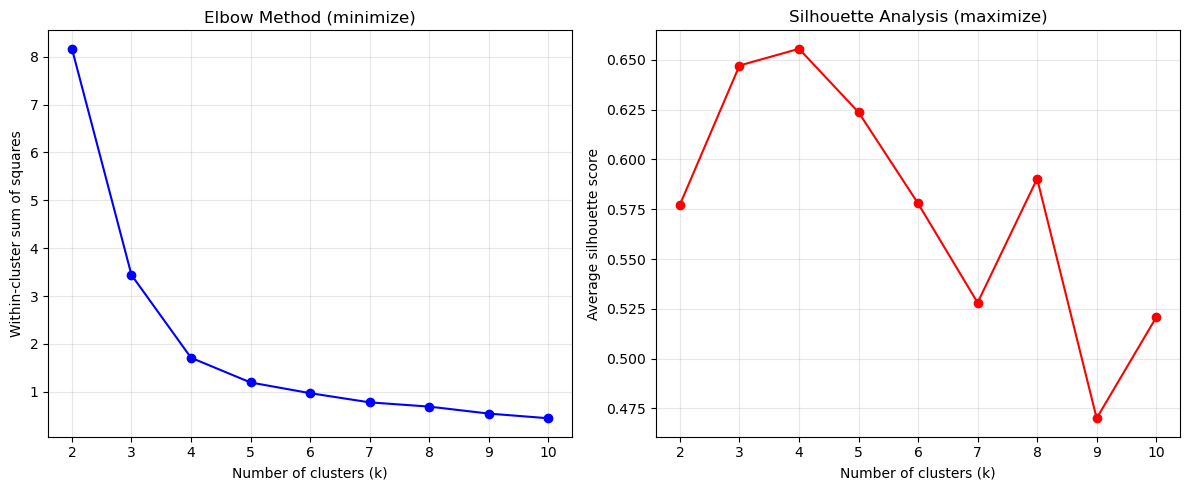

K-means evaluation results:
    k   inertia  silhouette
0   2  8.165185    0.577374
1   3  3.440244    0.647201
2   4  1.711057    0.655597
3   5  1.195037    0.623720
4   6  0.971511    0.577913
5   7  0.779553    0.528073
6   8  0.691093    0.590350
7   9  0.545214    0.470026
8  10  0.447553    0.520681


In [5]:
# Set random seed for reproducibility
np.random.seed(123)


def evaluate_kmeans_clustering(data, k_range=range(2, 11)):
    """
    Evaluate k-means clustering using elbow method and silhouette analysis
    """
    results = []

    for k in k_range:
        # Fit k-means
        kmeans = KMeans(n_clusters=k, random_state=123, n_init=25, init='random')
        labels = kmeans.fit_predict(data)

        # Calculate metrics
        inertia = kmeans.inertia_  # Within-cluster sum of squares
        silhouette_avg = silhouette_score(data, labels)

        results.append({"k": k, "inertia": inertia, "silhouette": silhouette_avg})

    return pd.DataFrame(results)


# Evaluate k-means clustering
X = mca_coords[["dim_1", "dim_2"]].values
kmeans_results = evaluate_kmeans_clustering(X)

# Create evaluation plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow plot
ax1.plot(kmeans_results["k"], kmeans_results["inertia"], "bo-")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Within-cluster sum of squares")
ax1.set_title("Elbow Method (minimize)")
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(kmeans_results["k"], kmeans_results["silhouette"], "ro-")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Average silhouette score")
ax2.set_title("Silhouette Analysis (maximize)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("K-means evaluation results:")
print(kmeans_results)

:::callout-tip

Check out the `yellowbrick` library to see how to implement the elbow and silhouette methods in a simpler way (see for example [this page](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html#quick-method))
:::

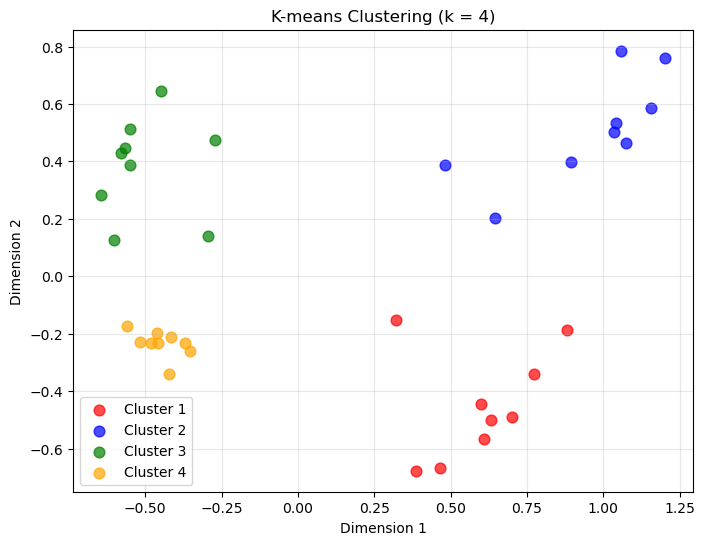

In [6]:
# Create final clustering with chosen k
optimal_k = 4  # Choose based on your evaluation plots

# Fit final k-means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=123, n_init=25, init='random')
kmeans_labels = final_kmeans.fit_predict(X)

# Visualize final clustering
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
for i in range(optimal_k):
    mask = kmeans_labels == i
    plt.scatter(mca_coords.loc[mask, 'dim_1'], 
               mca_coords.loc[mask, 'dim_2'], 
               c=colors[i], 
               label=f'Cluster {i+1}',
               s=60,
               alpha=0.7)

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title(f'K-means Clustering (k = {optimal_k})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Quick Study Questions:**
- What does the range(2, 11) create in our evaluation?
- Why do we use multiple random initializations (n_init=25)?
- What are the two evaluation methods being calculated?

------------------------------------------------------------------------

### Step 2: Apply to K-means++ (10 minutes)

**Your Task:** Modify the template for enhanced k-means with better initialization.

**Key change:** K-means++ initialization is actually the default in `scikit-learn`'s KMeans!

In [7]:
# Find optimal k using k-means++

In [8]:
# Build final model and plot the results

**Questions:**
1. Do you notice differences in stability compared to basic k-means?
2. Does the optimal k suggestion change?

------------------------------------------------------------------------

### Step 3: Apply to k-medoids (10 min)

**Your Task:** Adapt the k-means template for k-medoids clustering.

💡*Hint*: Use the `kmedoids` library for your code (see [documentation](https://python-kmedoids.readthedocs.io/en/latest))

**Questions** 

1. What optimal k do the elbow and silhouette methods suggest? 
2. How do k-medoids results compare to k-means?



In [9]:
# find optimal k using kmedoids

In [10]:
# build final model and plot the results

------------------------------------------------------------------------

### Step 4: Compare all three methods (10 minutes)

Create final clusterings using your chosen optimal k for all three methods:

In [11]:
# Code here

**Discussion Questions:**
1. Which evaluation method (elbow vs silhouette) was most reliable across algorithms?
2. Which clustering algorithm produced the best results for this dataset?
3. What are the key trade-offs between the three methods?

------------------------------------------------------------------------

## Part 3: DBSCAN - Density-Based Clustering (30 minutes)

DBSCAN is fundamentally different:
- **No need to specify k**
- **Finds arbitrary shapes**
- **Identifies noise points**
- **Key parameters:** `eps` (neighborhood radius) and `min_samples` (minimum points)

### Task 4: Basic DBSCAN

In [12]:
# Start with reasonable parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Check results
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise}")
print(f"Cluster labels: {np.unique(dbscan_labels)}")

Clusters found: 2
Noise points: 0
Cluster labels: [0 1]


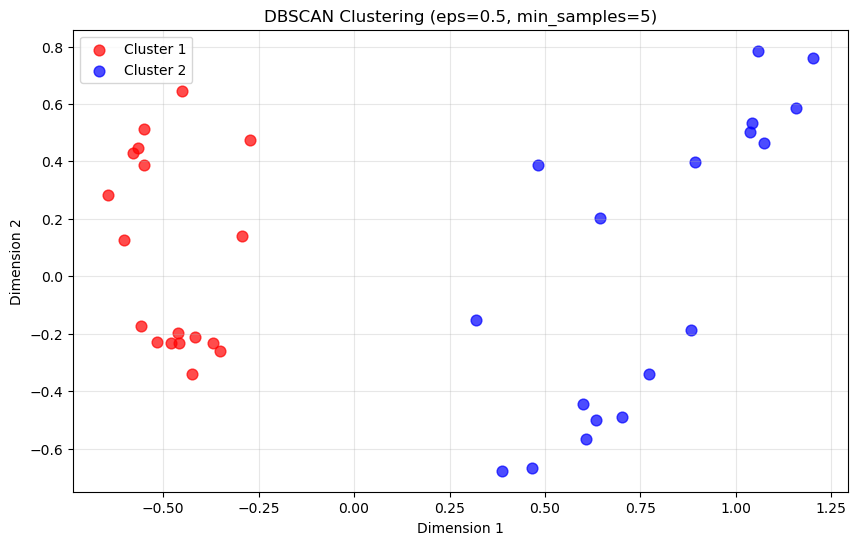

In [13]:
# Visualize DBSCAN results
plt.figure(figsize=(10, 6))

# Plot clustered points
for i in range(n_clusters):
    mask = dbscan_labels == i
    plt.scatter(mca_coords.loc[mask, 'dim_1'], 
               mca_coords.loc[mask, 'dim_2'], 
               c=colors[i % len(colors)], 
               label=f'Cluster {i+1}',
               s=60,
               alpha=0.7)

# Plot noise points
if n_noise > 0:
    noise_mask = dbscan_labels == -1
    plt.scatter(mca_coords.loc[noise_mask, 'dim_1'], 
               mca_coords.loc[noise_mask, 'dim_2'], 
               c='black', 
               marker='x', 
               s=60, 
               label='Noise',
               alpha=0.8)

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title(f'DBSCAN Clustering (eps=0.5, min_samples=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 5: Experiment with Epsilon

Try different `eps` values and observe the effects:

In [14]:
# Code here

**Key Questions:**
1. How does changing epsilon affect cluster formation?
2. What happens to noise points as epsilon changes?
3. Should all points belong to a cluster?
4. Which epsilon value seems most appropriate?

### Task 6: Final Comparison

Create side-by-side plots comparing your best k-means, k-means++, and DBSCAN results:

In [15]:
# Code here

**Discussion Questions:**
1. Which method captures the structure of your data best?
2. When would you choose DBSCAN over k-means/k-medoids?
3. What are the advantages of identifying noise points?

------------------------------------------------------------------------

## Summary Discussion

**Reflect on:**
- Which clustering method worked best for this dataset and why?
- How important was the choice of evaluation method?
- What are the key considerations when choosing clustering algorithms?
- When might you prefer density-based over centroid-based methods?

## Key Takeaways

- **Template approach:** Similar code patterns work across clustering methods
- **Evaluation matters:** Elbow and silhouette can give different suggestions
- **No universal best:** Choice depends on data characteristics and goals
- **DBSCAN advantages:** Handles noise and arbitrary shapes, no k required

## Homework Challenge

Apply these clustering methods to a dataset from your own field. Which method works best and why?

### Additional Python-Specific Notes

**Key Python Libraries Used:**
- `sklearn.cluster`: KMeans, DBSCAN
- `kmedoids`: KMedoids (PAM implementation)
- `sklearn.metrics`: silhouette_score, silhouette_samples
- `matplotlib.pyplot`: Plotting and visualization
- `pandas`: Data manipulation and analysis
- `numpy`: Numerical computations
- `yellowbrick`: elbow and silhouette plots 

**Installation Requirements:**
```bash
conda install -c conda-forge scikit-learn matplotlib pandas numpy seaborn kmedoids
```

Optionally:

```bash
pip install yellowbrick
```

**Performance Tips:**
- Use `n_init=25` for k-means to ensure stable results
- Set `random_state` for reproducible results
- Consider data scaling if features have very different ranges
- For large datasets, consider using `MiniBatchKMeans` instead of `KMeans`